In [10]:
import warnings
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

# Suppress warning messages during pipeline execution
warnings.filterwarnings('ignore')

print('====================================================================')
print('=== COMPONENT 3: INVENTORY & DEMAND FORECASTING ANALYTICS ========')
print('====================================================================\n')


=== COMPONENT 3: INVENTORY & DEMAND FORECASTING ANALYTICS ========



In [11]:
# =========================================================================
# STEP 1: DATA LOADING & PRELIMINARY CLEANING
# =========================================================================
# Load shop inventory sales dataset
df = pd.read_csv('shop inventory.csv')

# Remove duplicate records to prevent data leakage and overfitting
df = df.drop_duplicates().reset_index(drop=True)

# Drop unused/target-leakage columns safely
df = df.drop(columns=['target_next_month_price'], errors='ignore')

# Separate dependent target variable (y) and independent features (X)
y = df['target_units_sold']
X = df.drop(columns=['target_units_sold'])


In [12]:
# =========================================================================
# STEP 2: RECOMMENDED ML UPGRADES - FEATURE ENGINEERING & RISK ENGINE
# =========================================================================

# --- Feature Engineering A: Sales Momentum (Lag Features) ---
# Calculate monthly demand acceleration/momentum based on historical sales
if 'lag1_units' in X.columns and 'lag2_units' in X.columns:
  X['sales_momentum'] = X['lag1_units'] - X['lag2_units']

# --- Feature Engineering B: Stock Cover Ratio ---
# Measure inventory runway (how many months current stock can sustain average sales)
if 'current_stock' in X.columns and 'historical_avg_sales' in X.columns:
  X['stock_cover_ratio'] = X['current_stock'] / (
      X['historical_avg_sales'] + 1e-5
  )

# --- Feature Engineering C: Temporal/Seasonality Extraction ---
# Extract cyclical time components if raw date column exists
if 'date' in X.columns:
  X['date'] = pd.to_datetime(X['date'], errors='coerce')
  X['month'] = X['date'].dt.month
  X['quarter'] = X['date'].dt.quarter
  X['is_year_end_peak'] = X['month'].isin([11, 12]).astype(int)
  X = X.drop(columns=['date'], errors='ignore')


In [13]:
# =========================================================================
# STEP 3: TEMPORAL TRAIN-TEST SPLITING & PREPROCESSING SETUP
# =========================================================================
# Perform temporal split (prior years for training, recent year for validation)
if 'iso_year' in X.columns:
  train_mask = X['iso_year'] < 2024
  X_train, X_test = X[train_mask], X[~train_mask]
  y_train, y_test = y[train_mask], y[~train_mask]
else:
  # Fallback train-test split if iso_year column is absent
  from sklearn.model_selection import train_test_split

  X_train, X_test = X, y
  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=42
  )

print(f'Train Dataset Size : {len(X_train)}')
print(f'Test Dataset Size  : {len(X_test)}\n')

# Identify categorical and numerical columns dynamically
cat_cols = (
    ['item', 'category']
    if 'item' in X.columns
    else X.select_dtypes(include=['object', 'category']).columns.tolist()
)
num_cols = [c for c in X.columns if c not in cat_cols]

# Build Scikit-Learn ColumnTransformer pipeline
preprocessor = ColumnTransformer([
    (
        'cat',
        Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore')),
        ]),
        cat_cols,
    ),
    (
        'num',
        Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('sc', StandardScaler()),
        ]),
        num_cols,
    ),
])


Train Dataset Size : 1773
Test Dataset Size  : 692



In [14]:
# =========================================================================
# STEP 4: REGRESSION MODEL PIPELINES & XGBOOST INTEGRATION
# =========================================================================
# Define regression baseline models wrapped in pipelines
models = {
    'LinearRegression': Pipeline(
        [('pre', preprocessor), ('m', LinearRegression())]
    ),
    'DecisionTree': Pipeline([
        ('pre', preprocessor),
        ('m', DecisionTreeRegressor(max_depth=8, random_state=42)),
    ]),
    'RandomForest': Pipeline([
        ('pre', preprocessor),
        (
            'm',
            RandomForestRegressor(
                n_estimators=300, max_depth=12, n_jobs=-1, random_state=42
            ),
        ),
    ]),
    'GradientBoosting': Pipeline([
        ('pre', preprocessor),
        (
            'm',
            GradientBoostingRegressor(
                n_estimators=250,
                learning_rate=0.05,
                max_depth=5,
                random_state=42,
            ),
        ),
    ]),
}

# Integrate XGBoost Regressor if library is installed
try:
  from xgboost import XGBRegressor

  models['XGBoost'] = Pipeline([
      ('pre', preprocessor),
      (
          'm',
          XGBRegressor(
              n_estimators=300,
              max_depth=5,
              learning_rate=0.05,
              subsample=0.9,
              random_state=42,
          ),
      ),
  ])
except ImportError:
  print('Notice: XGBoost not installed. Running standard Sklearn models.')


In [15]:
# =========================================================================
# STEP 5: MODEL TRAINING, BENCHMARKING & CHAMPION SELECTION
# =========================================================================
print('=== Running 5-Model Regression Benchmarking ===')
scores = {}
metrics_summary = {}

# Evaluate each model on MAE, RMSE, and R2 Score
for name, m in models.items():
  m.fit(X_train, y_train)
  p = m.predict(X_test)

  r2 = r2_score(y_test, p)
  mae = mean_absolute_error(y_test, p)
  rmse = mean_squared_error(y_test, p) ** 0.5

  scores[name] = r2
  metrics_summary[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}

  print(f'  {name:18s} | MAE: {mae:6.2f} | RMSE: {rmse:6.2f} | R²: {r2:.3f}')

# Select Champion Demand Forecast Model based on highest R² score
best_name = max(scores, key=scores.get)
print(f'\n🏆 Champion Demand Model Selected: {best_name}')

model = models[best_name]
model.fit(X_train, y_train)
pred = model.predict(X_test)

# Calculate final test set metrics
final_mae = mean_absolute_error(y_test, pred)
final_rmse = mean_squared_error(y_test, pred) ** 0.5
final_r2 = r2_score(y_test, pred)

print('\n===================================================')
print(f'=== Champion Model ({best_name}) Performance ===')
print('===================================================')
print(f'MAE  (Mean Absolute Error) : {final_mae:.2f} units')
print(f'RMSE (Root Mean Sq Error)  : {final_rmse:.2f} units')
print(f'R² Score (Variance Explained): {final_r2:.3f}\n')


=== Running 5-Model Regression Benchmarking ===
  LinearRegression   | MAE:  23.56 | RMSE:  31.77 | R²: 0.921
  DecisionTree       | MAE:  26.63 | RMSE:  38.69 | R²: 0.883
  RandomForest       | MAE:  21.56 | RMSE:  29.74 | R²: 0.931
  GradientBoosting   | MAE:  21.67 | RMSE:  29.88 | R²: 0.930
  XGBoost            | MAE:  21.76 | RMSE:  29.96 | R²: 0.930

🏆 Champion Demand Model Selected: RandomForest

=== Champion Model (RandomForest) Performance ===
MAE  (Mean Absolute Error) : 21.56 units
RMSE (Root Mean Sq Error)  : 29.74 units
R² Score (Variance Explained): 0.931



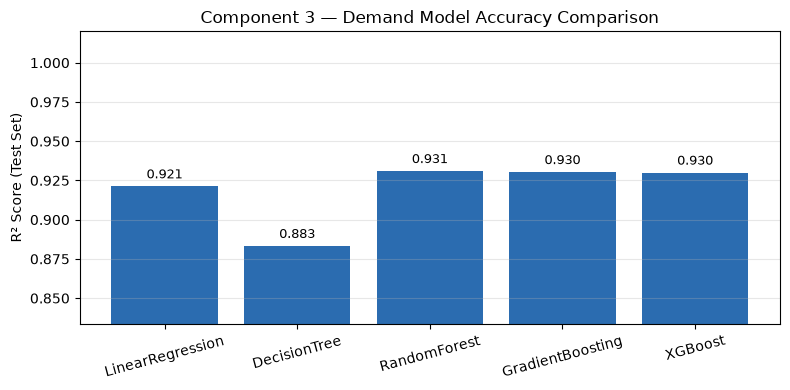

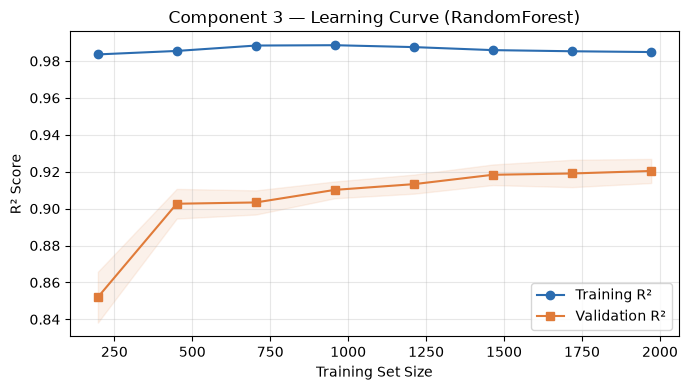

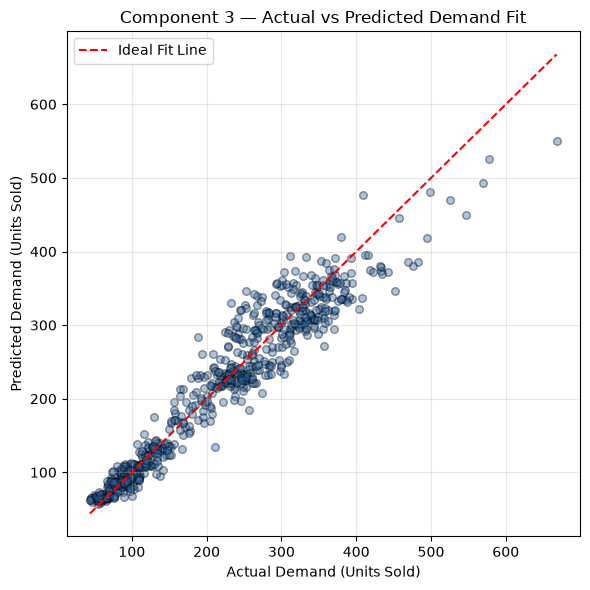

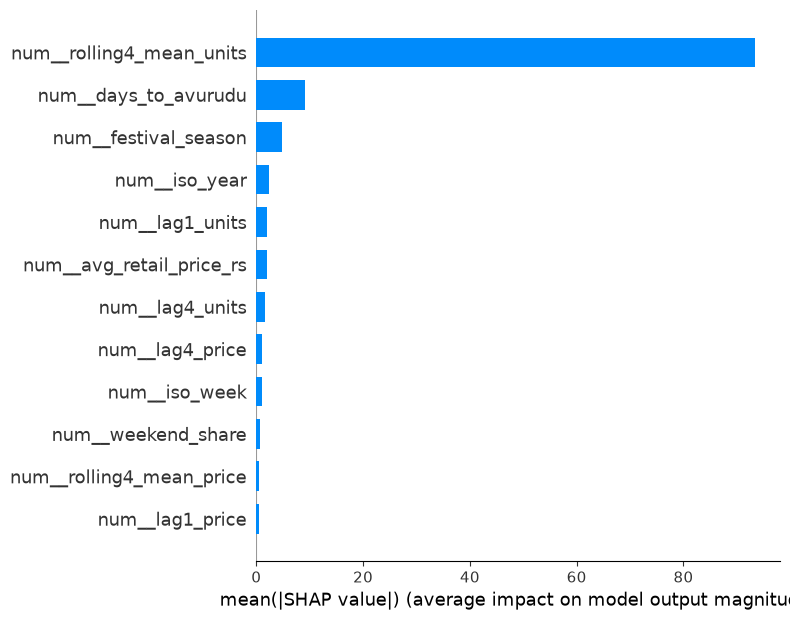

In [16]:
# =========================================================================
# STEP 6: VISUALIZATIONS & DIAGNOSTIC CHARTS
# =========================================================================

# --- Chart 1: R² Score Benchmarking Bar Chart ---
plt.figure(figsize=(8, 4))
bars = plt.bar(scores.keys(), scores.values(), color='#2b6cb0')
for b, v in zip(bars, scores.values()):
  plt.text(
      b.get_x() + b.get_width() / 2,
      v + 0.005,
      f'{v:.3f}',
      ha='center',
      fontsize=9,
  )
plt.ylim(
    min(scores.values()) - 0.05 if min(scores.values()) > 0 else 0,
    1.02,
)
plt.ylabel('R² Score (Test Set)')
plt.title('Component 3 — Demand Model Accuracy Comparison')
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# --- Chart 2: Model Learning Curve ---
sizes, tr, val = learning_curve(
    model,
    X,
    y,
    cv=KFold(5, shuffle=True, random_state=42),
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1,
)

plt.figure(figsize=(7, 4))
plt.plot(sizes, tr.mean(1), 'o-', label='Training R²', color='#2b6cb0')
plt.plot(sizes, val.mean(1), 's-', label='Validation R²', color='#e07b39')
plt.fill_between(
    sizes,
    val.mean(1) - val.std(1),
    val.mean(1) + val.std(1),
    alpha=0.1,
    color='#e07b39',
)
plt.xlabel('Training Set Size')
plt.ylabel('R² Score')
plt.title(f'Component 3 — Learning Curve ({best_name})')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Chart 3: Actual vs Predicted Demand Scatter Plot ---
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred, alpha=0.4, color='#2b6cb0', edgecolors='k', s=30)
lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
plt.plot(lims, lims, 'r--', label='Ideal Fit Line')
plt.xlabel('Actual Demand (Units Sold)')
plt.ylabel('Predicted Demand (Units Sold)')
plt.title('Component 3 — Actual vs Predicted Demand Fit')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Chart 4: SHAP Explainability Plot ---
try:
  import shap

  Xt = model.named_steps['pre'].transform(X_test[:1000])
  Xt = Xt.toarray() if hasattr(Xt, 'toarray') else np.asarray(Xt)
  Xt = Xt.astype(float)

  feat_names = model.named_steps['pre'].get_feature_names_out()
  explainer = shap.TreeExplainer(model.named_steps['m'])
  shap_values = explainer.shap_values(Xt)

  plt.figure(figsize=(8, 4.5))
  shap.summary_plot(
      shap_values,
      features=Xt,
      feature_names=feat_names,
      plot_type='bar',
      max_display=12,
  )
except Exception as e:
  print(f'Notice: SHAP analysis skipped ({e}).')


In [17]:
# =========================================================================
# STEP 7: RECOMMENDED ML UPGRADE - DYNAMIC SAFETY STOCK & REORDER ENGINE
# =========================================================================
print('===================================================')
print('=== INVENTORY REORDER & SAFETY STOCK ADVISORY ===')
print('===================================================')

# Select sample test item for inference demonstration
sample_idx = 0
sample_item = X_test.iloc[[sample_idx]].copy()
predicted_demand = max(0, round(model.predict(sample_item)[0]))

# --- Dynamic Safety Stock Calculation (Formula: Z * std_dev_error * sqrt(lead_time)) ---
# Service Level Factor Z = 1.65 (95% Service Level Guarantee)
z_score = 1.65
lead_time_months = 1.0  # Assumed lead time
dynamic_safety_stock = round(z_score * final_rmse * np.sqrt(lead_time_months))

# Recommended inventory reorder level (Demand Forecast + Dynamic Safety Buffer)
recommended_stock_level = predicted_demand + dynamic_safety_stock

# Stockout Risk Assessment
current_stock = (
    sample_item['current_stock'].values[0]
    if 'current_stock' in sample_item.columns
    else 0
)
stock_shortage = recommended_stock_level - current_stock

if stock_shortage > 0:
  action_advice = f'🚩 REORDER REQUIRED: Purchase {stock_shortage} units immediately to prevent stockout.'
else:
  action_advice = (
      '✅ ADEQUATE INVENTORY: Current stock covers forecasted demand & safety'
      ' buffer.'
  )

print(f'Sample Ref Index          : {sample_idx}')
print(f'Forecasted Demand (Units) : {predicted_demand} units')
print(f'Dynamic Safety Stock (95%): {dynamic_safety_stock} units')
print(f'Optimal Inventory Level   : {recommended_stock_level} units')
print(f'Inventory Action Advice   : {action_advice}')


=== INVENTORY REORDER & SAFETY STOCK ADVISORY ===
Sample Ref Index          : 0
Forecasted Demand (Units) : 110 units
Dynamic Safety Stock (95%): 49 units
Optimal Inventory Level   : 159 units
Inventory Action Advice   : 🚩 REORDER REQUIRED: Purchase 159 units immediately to prevent stockout.


In [18]:
# =========================================================================
# STEP 8: MODEL ARTIFACT SERIALIZATION
# =========================================================================
# Save pipeline artifact to disk
model_filename = 'component3_demand_forecast_model.pkl'
joblib.dump(model, model_filename)
print(f'\n✅ Model saved successfully as "{model_filename}"')


✅ Model saved successfully as "component3_demand_forecast_model.pkl"
